# MSFT Next-Day Direction Predictor — Iteration 4: ARIMA-Derived Direction Signal

**Author:** Lucan den Dekker  
**Project:** ADSAI Group 15 Block D Capstone  
**Date:** 2026-06-03  

---

**Improvements over Iteration 3**

| Change | Reason |
|---|---|
| ARIMA model replaces direct binary classifier | Time series model purpose-built for sequential price autocorrelation |
| `pmdarima.auto_arima` for optimal ARIMA(p,d,q) order | Automatic AIC-minimising search — avoids manual trial-and-error on the (p,q) grid |
| Walk-forward one-step-ahead evaluation | Each forecast uses all available history up to that day — zero lookahead bias |
| ARIMA trained on last 2 years only | Keeps coefficients calibrated on the current market regime |
| Direction derived from ARIMA price forecast | UP if predicted close > today's close by > threshold %; DOWN if below |
| Threshold sweep (Section 5b) | Finds the confidence threshold that maximises precision vs coverage |

| Section | Content |
|---|---|
| 0 | Imports and Setup |
| 1 | Load Data |
| 2 | Feature Engineering and Stationarity Analysis |
| 3 | Train/Test Split |
| 4 | Baseline Model |
| 5 | ARIMA: Order Selection, Walk-Forward Forecast, Direction Signal |
| 5b | Threshold Sweep: Precision vs Coverage |
| 6 | Model Comparison (ARIMA vs Baseline) |
| 7 | Error Analysis |
| 8 | Rolling-Window Cross-Validation |
| 9 | Business Value Interpretation |

In [20]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib pmdarima statsmodels

Note: you may need to restart the kernel to use updated packages.


---
## Section 0 — Imports and Setup

All dependencies are imported upfront so that import errors fail fast.  
`pmdarima` provides `auto_arima` for automatic ARIMA(p,d,q) order selection and an
online-updatable model for walk-forward forecasting via `.update()`.  
`statsmodels.tsa.stattools.adfuller` performs the Augmented Dickey-Fuller unit-root
test to confirm whether differencing is needed before fitting ARIMA.  
`RANDOM_SEED = 42` is applied to all stochastic components for full reproducibility.

**Key design choices:**
- `DATA_PATH` tries the current `data/processed/` location first, then falls back to the
  legacy `msft-forecaster/data/processed/` path used in it1–3.
- `NEUTRAL_THRESHOLD = 0.2` matches it3 so that direction labels are directly comparable.

In [21]:
# Standard library
import warnings
import logging
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-learn
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# XGBoost
from xgboost import XGBClassifier
import xgboost as xgb_lib

# ARIMA
import pmdarima as pm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Persistence
import joblib

# Reproducibility
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Logging — timestamps + severity levels persist in saved notebook outputs
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("msft_modelling")

# Plot style
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("seaborn-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

# Neutral zone threshold — matches it3 for comparable direction labels
NEUTRAL_THRESHOLD: float = 0.2


def find_project_root(marker: str = "README.md") -> Path:
    """Walk up the directory tree until a marker file is found."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    logger.warning("Project root not found; falling back to cwd.")
    return current


PROJECT_ROOT = find_project_root()

# Try the primary data location; fall back to legacy path from it1-3
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "msft_merged.csv"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "msft-forecaster" / "data" / "processed" / "msft_merged.csv"

MODELS_DIR = PROJECT_ROOT / "models" / "lucan"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root : %s", PROJECT_ROOT)
logger.info("Data path    : %s", DATA_PATH)
logger.info("Models dir   : %s", MODELS_DIR)

2026-06-03 12:05:53 | INFO | Project root : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15
2026-06-03 12:05:53 | INFO | Data path    : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\data\processed\msft_merged.csv
2026-06-03 12:05:53 | INFO | Models dir   : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan


---
## Section 1 — Load Data

Same as it3: full 2015–2026 dataset with no date cutoff.
The merged CSV contains daily OHLCV data for MSFT joined with gold, oil, VIX,
and SPY close prices.

ARIMA operates on the raw `Close` price series — not on engineered features — so
the raw dataframe `df_raw` is retained alongside the feature-engineered `df`.

In [22]:
def load_data(path: Path) -> pd.DataFrame:
    """Load the MSFT merged CSV and return a date-indexed DataFrame.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with a DatetimeIndex sorted ascending.

    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist.
    ValueError
        If no date column is detected.
    """
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")

    df = pd.read_csv(path)

    date_col = next(
        (c for c in df.columns if c.lower() in ("date", "datetime", "timestamp")),
        None,
    )
    if date_col is None:
        raise ValueError(f"No date column found. Columns: {list(df.columns)}")

    df[date_col] = pd.to_datetime(df[date_col])
    df.set_index(date_col, inplace=True)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    return df


df_raw = load_data(DATA_PATH)
logger.info(
    "Loaded: shape=%s | %s to %s",
    df_raw.shape,
    df_raw.index.min().date(),
    df_raw.index.max().date(),
)

missing = int(df_raw.isnull().sum().sum())
if missing > 0:
    logger.warning("%d missing values found; dropping affected rows.", missing)
    df_raw = df_raw.dropna()
else:
    logger.info("No missing values found.")

logger.info("Using full dataset: %d rows", len(df_raw))
print(df_raw.head())

2026-06-03 12:05:53 | INFO | Loaded: shape=(2818, 9) | 2015-02-17 to 2026-04-30
2026-06-03 12:05:53 | INFO | No missing values found.
2026-06-03 12:05:53 | INFO | Using full dataset: 2818 rows


             Open     High    Low   Close      Volume   gold_close  oil_close  \
Date                                                                            
2015-02-17  43.97  44.0000  43.19  43.580  33695149.0  1208.099976  53.529999   
2015-02-18  43.63  43.7000  43.39  43.530  27111657.0  1199.699951  52.139999   
2015-02-19  43.18  43.5263  43.05  43.500  27556420.0  1207.099976  51.160000   
2015-02-20  43.51  43.8800  43.29  43.855  29721133.0  1204.400024  50.340000   
2015-02-23  43.70  44.1900  43.65  44.150  32518754.0  1200.300049  49.450001   

              vix   spy_close  
Date                           
2015-02-17  15.80  174.000732  
2015-02-18  15.45  174.017288  
2015-02-19  15.29  173.893082  
2015-02-20  14.30  174.936493  
2015-02-23  14.56  174.911667  


---
## Section 2 — Feature Engineering and Stationarity Analysis

### Feature Engineering

Identical to it3: 14 scale-invariant technical and macro features are computed
for use by the it3 reference classifiers (RF and XGBoost) and for generating
consistent binary direction labels (`target`) to evaluate all models.

### Stationarity Analysis

ARIMA requires the input time series to be **stationary** (constant mean and
variance over time). Raw stock prices are non-stationary — they trend upward
over the full history. The **Augmented Dickey-Fuller (ADF)** test formalises this:

- **H₀**: the series has a unit root (non-stationary)
- **H₁**: the series is stationary
- If p-value < 0.05, reject H₀ → stationary

For stock prices we expect to fail to reject H₀ on the raw series and reject it
on the first-differenced series. This confirms **d = 1** in ARIMA(p, **d**, q).

ACF and PACF plots of the differenced series guide the choice of q (MA order)
and p (AR order) — though `auto_arima` in Section 5 performs this search automatically.

2026-06-03 12:05:53 | INFO | Threshold=0.2%  DOWN(0): 1082 | UP(1): 1273
2026-06-03 12:05:53 | INFO | Dataset shape after feature engineering: (2355, 24)
2026-06-03 12:05:53 | INFO | ADF Raw close price                      stat= -0.6400  p=0.8617  NON-STATIONARY
2026-06-03 12:05:53 | INFO | ADF First-differenced close              stat=-17.6131  p=0.0000  STATIONARY


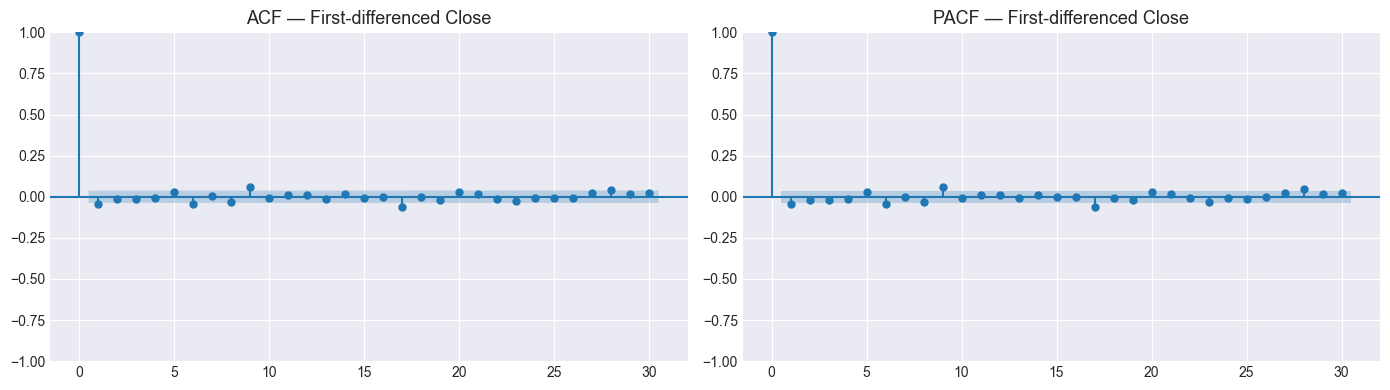

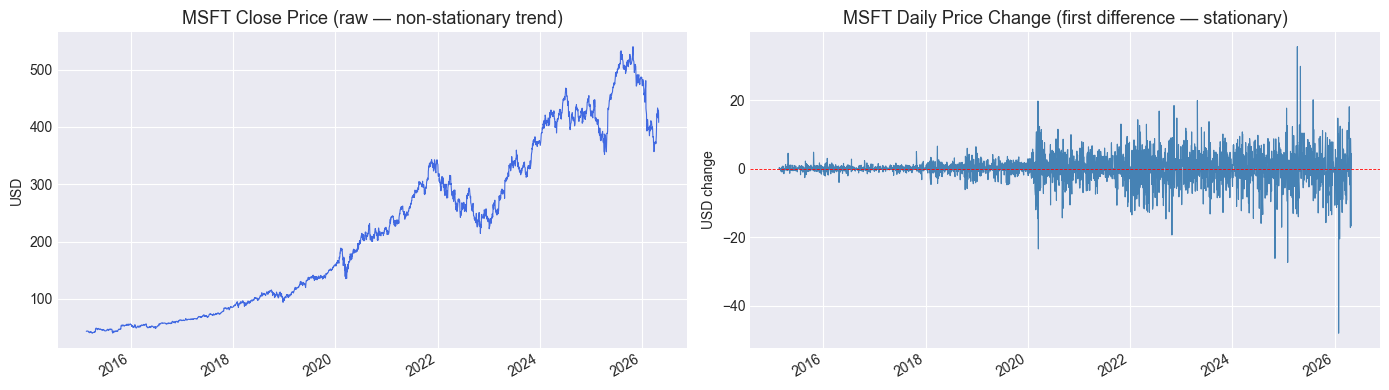

In [23]:
def _detect_column(df: pd.DataFrame, candidates: list) -> str:
    """Return the first column name matching any candidate (case-insensitive)."""
    col_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in col_lower:
            return col_lower[name]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")


def _rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Compute RSI using Wilder's exponential smoothing."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def engineer_features(df: pd.DataFrame, threshold: float = NEUTRAL_THRESHOLD) -> pd.DataFrame:
    """Add scale-invariant technical and macro features, plus binary target.

    Identical to it3: 14 features, ±0.2 % neutral threshold.
    All features use only data available at close on day t (no lookahead bias).

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged MSFT dataframe with a DatetimeIndex.
    threshold : float
        Minimum absolute next-day return (%) to label as UP or DOWN.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered features and integer 'target' column.
    """
    df = df.copy()

    close  = df[_detect_column(df, ["close", "msft_close", "adj close", "adj_close"])]
    high   = df[_detect_column(df, ["high",  "msft_high"])]
    low    = df[_detect_column(df, ["low",   "msft_low"])]
    volume = df[_detect_column(df, ["volume", "msft_volume"])]
    gold   = df[_detect_column(df, ["gold_close", "gold close", "gold", "gc=f_close"])]
    oil    = df[_detect_column(df, ["oil_close",  "oil close",  "oil",  "cl=f_close", "wti_close"])]
    vix    = df[_detect_column(df, ["vix", "^vix", "vix_close"])]
    spy    = df[_detect_column(df, ["spy_close", "spy"])]

    sma5  = close.rolling(5).mean()
    sma10 = close.rolling(10).mean()

    df["daily_return"]       = close.pct_change() * 100
    df["momentum_5"]         = close.pct_change(5) * 100
    df["momentum_10"]        = close.pct_change(10) * 100
    df["rsi_14"]             = _rsi(close)
    df["close_to_sma5_pct"]  = (close - sma5)  / sma5  * 100
    df["close_to_sma10_pct"] = (close - sma10) / sma10 * 100
    df["sma_crossover"]      = sma5 / sma10
    df["price_range_pct"]    = (high - low) / close * 100
    df["rolling_std_5"]      = close.rolling(5).std()
    df["volume_ratio"]       = volume / volume.rolling(20).mean()
    df["lag_gold_return"]    = gold.pct_change().shift(1) * 100
    df["lag_oil_return"]     = oil.pct_change().shift(1) * 100
    df["lag_vix_1"]          = vix.shift(1)
    df["lag_spy_return"]     = spy.pct_change().shift(1) * 100

    next_day_return = (close.shift(-1) - close) / close * 100
    df["target"] = np.select(
        [next_day_return > threshold, next_day_return < -threshold],
        [1, 0],
        default=np.nan,
    )
    df = df.dropna(subset=["target"])
    df["target"] = df["target"].astype(int)
    df = df.dropna()

    class_counts = df["target"].value_counts().sort_index()
    logger.info(
        "Threshold=%.1f%%  DOWN(0): %d | UP(1): %d",
        threshold,
        class_counts.get(0, 0),
        class_counts.get(1, 0),
    )
    logger.info("Dataset shape after feature engineering: %s", df.shape)
    return df


IT3_FEATURES = [
    "rsi_14",
    "momentum_5",
    "momentum_10",
    "daily_return",
    "price_range_pct",
    "close_to_sma5_pct",
    "close_to_sma10_pct",
    "sma_crossover",
    "rolling_std_5",
    "volume_ratio",
    "lag_gold_return",
    "lag_oil_return",
    "lag_vix_1",
    "lag_spy_return",
]

df = engineer_features(df_raw)

# ── Stationarity analysis on the full raw close series ───────────────────────
close_col  = _detect_column(df_raw, ["close", "msft_close", "adj close", "adj_close"])
close_all  = df_raw[close_col].dropna()
close_diff = close_all.diff().dropna()


def adf_summary(series: pd.Series, label: str) -> None:
    """Run ADF test and print a one-line result."""
    result    = adfuller(series, autolag="AIC")
    stationary = result[1] < 0.05
    logger.info(
        "ADF %-35s  stat=%8.4f  p=%.4f  %s",
        label, result[0], result[1],
        "STATIONARY" if stationary else "NON-STATIONARY",
    )


adf_summary(close_all,  "Raw close price")
adf_summary(close_diff, "First-differenced close")

# ACF / PACF of the differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(close_diff,  lags=30, ax=axes[0], title="ACF — First-differenced Close")
plot_pacf(close_diff, lags=30, ax=axes[1], title="PACF — First-differenced Close")
plt.tight_layout()
plt.show()

# Raw vs differenced price chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(close_all.index,  close_all.values,  color="royalblue", linewidth=0.8)
axes[0].set_title("MSFT Close Price (raw — non-stationary trend)")
axes[0].set_ylabel("USD")
axes[1].plot(close_diff.index, close_diff.values, color="steelblue", linewidth=0.8)
axes[1].axhline(0, color="red", linewidth=0.6, linestyle="--")
axes[1].set_title("MSFT Daily Price Change (first difference — stationary)")
axes[1].set_ylabel("USD change")
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

### Stationarity Interpretation

The ADF test is expected to confirm:
- **Raw close price**: p > 0.05 → fail to reject H₀ → **non-stationary** (MSFT has trended from $45 to $450 over 10 years)
- **First-differenced close**: p < 0.05 → reject H₀ → **stationary** (daily price changes fluctuate around a constant mean)

This confirms **d = 1** is the correct differencing order. ARIMA(p, 1, q) models daily
price *changes* rather than price levels — a stationary, mean-reverting process.

From the ACF/PACF of the differenced series:
- **ACF**: significant lags indicate the MA(q) order. A single significant spike → q = 1.
- **PACF**: significant lags indicate the AR(p) order. Two significant spikes → p = 2.

`auto_arima` in Section 5 will confirm the optimal (p, q) automatically via AIC.

---
## Section 3 — Train/Test Split

Two splits are created:

1. **Feature-engineered split** (`df_train` / `df_test`): provides consistent binary
   target labels (`target`) used to evaluate ARIMA's direction predictions.
   Uses the full 2015–2026 dataset with the same 80/20 split as it1–3.

2. **ARIMA close series** — limited to the **last 2 years before the test boundary**
   (~2022–2024, ≈ 504 trading days). Using only recent data keeps ARIMA's coefficients
   calibrated on the current market regime. Pre-2022 data (zero-rate era, COVID recovery)
   is structurally different and adds noise. Because ARIMA updates itself online via
   `.update()`, a shorter but more relevant window outperforms a larger stale one.

In [ ]:
# ── Feature-engineered split (for target labels only) ────────────────────────
split_idx = int(len(df) * 0.80)
df_train  = df.iloc[:split_idx]
df_test   = df.iloc[split_idx:]

logger.info(
    "Feature train: %d rows | %s to %s",
    len(df_train), df_train.index.min().date(), df_train.index.max().date(),
)
logger.info(
    "Feature test : %d rows | %s to %s",
    len(df_test), df_test.index.min().date(), df_test.index.max().date(),
)

y_test = df_test["target"]

# ── ARIMA close series split — last 2 years only ─────────────────────────────
ARIMA_TRAIN_YEARS = 2
test_start_date = df_test.index.min()
arima_cutoff    = test_start_date - pd.DateOffset(years=ARIMA_TRAIN_YEARS)

close_train = df_raw.loc[
    (df_raw.index >= arima_cutoff) & (df_raw.index < test_start_date),
    close_col,
].dropna()
close_test = df_raw.loc[df_raw.index >= test_start_date, close_col].dropna()

logger.info(
    "ARIMA train close: %d rows | %s to %s  (last %d years)",
    len(close_train),
    close_train.index.min().date(),
    close_train.index.max().date(),
    ARIMA_TRAIN_YEARS,
)
logger.info(
    "ARIMA test close : %d rows | %s to %s",
    len(close_test), close_test.index.min().date(), close_test.index.max().date(),
)

print(f"Feature test  : {len(df_test)} rows")
print(f"ARIMA train   : {len(close_train)} rows (last {ARIMA_TRAIN_YEARS} years)")
print(f"ARIMA test    : {len(close_test)} rows")

---
## Section 4 — Baseline Model (Majority-Class Classifier)

The majority-class baseline always predicts the most frequent class (UP, due to
MSFT's long-term upward trend). It establishes the performance floor.

In [ ]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute weighted classification metrics and return as a results dict.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Human-readable identifier.

    Returns
    -------
    dict
        Keys: 'Model', 'Accuracy', 'Precision', 'Recall', 'F1'.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    logger.info(
        "%s  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f",
        model_name, acc, prec, rec, f1,
    )
    return {
        "Model":     model_name,
        "Accuracy":  round(acc,  4),
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1":        round(f1,   4),
    }


def plot_confusion_matrix(y_true, y_pred, model_name: str) -> None:
    """Plot a seaborn heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True, fmt="d", cmap="Blues",
        xticklabels=["DOWN (0)", "UP (1)"],
        yticklabels=["DOWN (0)", "UP (1)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# Majority-class baseline: features don't affect DummyClassifier, use placeholder
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(np.zeros((len(y_test), 1)), y_test)
y_pred_dummy = dummy.predict(np.zeros((len(y_test), 1)))

baseline_metrics = evaluate_model(y_test, y_pred_dummy, "Baseline (Majority Class)")
print(classification_report(y_test, y_pred_dummy, target_names=["DOWN", "UP"]))

---
## Section 5 — ARIMA: Order Selection, Walk-Forward Forecast, Direction Signal

### Why ARIMA for direction prediction?

ARIMA(p, d, q) is the canonical statistical model for univariate time series.
It captures:
- **AR(p)**: autocorrelation — today's price depends on the last *p* prices
- **I(d)**: integration — *d* differences needed to achieve stationarity
- **MA(q)**: moving average of past forecast errors

Unlike the binary classifiers in it1–3, ARIMA does not classify direction directly.
Instead, it **forecasts the next-day closing price**. The direction is derived by
comparing the forecast with today's close:
- Predicted return > +0.2 % → **UP (1)**
- Predicted return < −0.2 % → **DOWN (0)**
- Otherwise → **neutral** (excluded, consistent with it1–3)

### Walk-Forward Evaluation

A static ARIMA model trained once will drift as the market evolves. The correct
evaluation protocol is **walk-forward one-step-ahead**:

1. Fit ARIMA on all training data → the **pre-trained model**
2. For each test day *t*: forecast close at *t+1* using `model.predict(n_periods=1)`
3. Call `model.update([actual_close_t])` — online parameter update with the new observation
4. Repeat for all test days

This simulates realistic deployment: the model is updated daily with fresh data without
full retraining. `pmdarima`'s `.update()` uses efficient recursive updating.

### Order Selection

`auto_arima` searches over (p, q) combinations with d=1 fixed (confirmed by ADF)
and selects the order that minimises the Akaike Information Criterion (AIC).

> **Note:** `auto_arima` and the walk-forward loop may take 1–3 minutes on CPU.

2026-06-03 12:05:54 | INFO | Running auto_arima on 502 training observations ...
2026-06-03 12:05:54 | INFO | auto_arima selected ARIMA(0, 1, 0)  AIC=3093.14
2026-06-03 12:05:54 | INFO | Walk-forward forecast over 564 test observations ...


Selected order: ARIMA(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  502
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1545.570
Date:                Wed, 03 Jun 2026   AIC                           3093.139
Time:                        12:05:54   BIC                           3097.356
Sample:                             0   HQIC                          3094.794
                                - 502                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        27.9960      1.494     18.742      0.000      25.068      30.924
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                13.53
Prob(Q):        

2026-06-03 12:06:03 | INFO | Walk-forward complete. 564 forecasts generated.
2026-06-03 12:06:03 | INFO | ARIMA model saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\arima_lucan_it4.pkl
2026-06-03 12:06:03 | INFO | ARIMA direction: 390 directional predictions, 81 neutral (excluded)
2026-06-03 12:06:03 | INFO | ARIMA Direction Signal  Acc=0.5051  Prec=0.5085  Rec=0.5051  F1=0.5051


              precision    recall  f1-score   support

        DOWN       0.48      0.54      0.51       184
          UP       0.54      0.48      0.50       206

    accuracy                           0.51       390
   macro avg       0.51      0.51      0.51       390
weighted avg       0.51      0.51      0.51       390



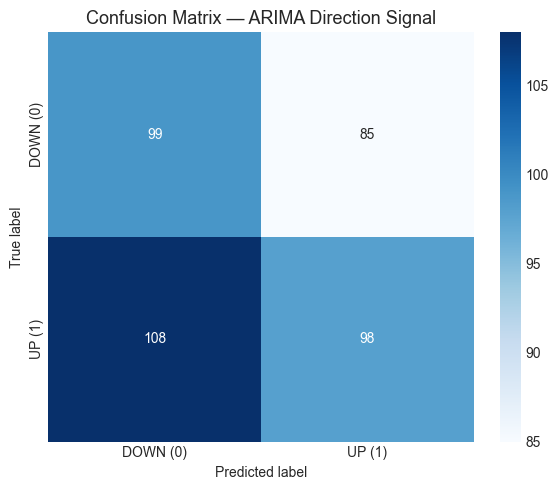

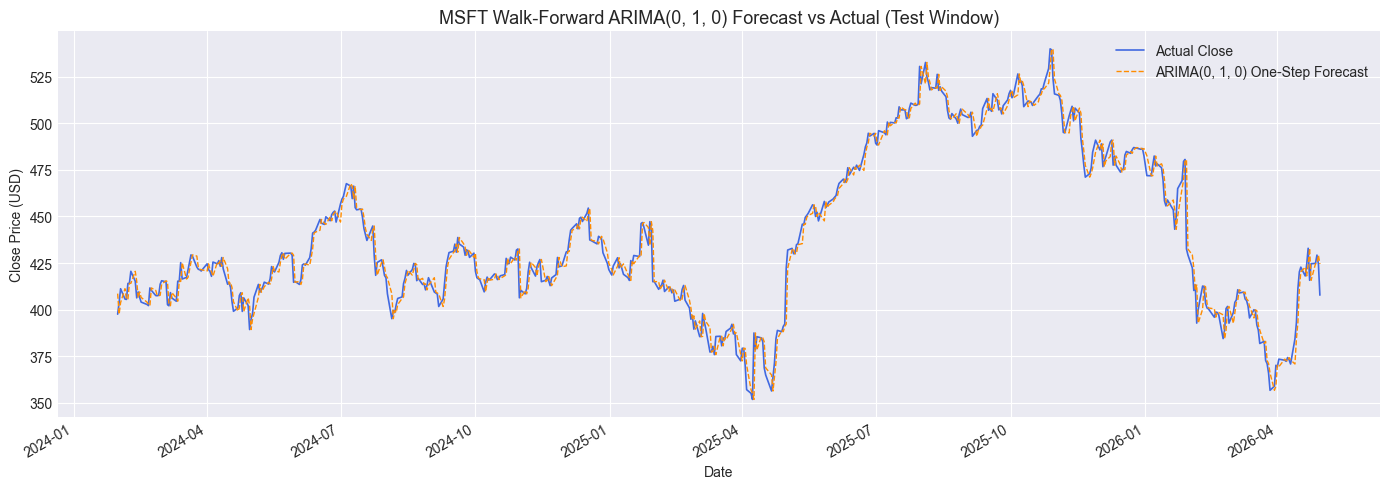

In [26]:
# ── Step 1: Automatic ARIMA order selection on training data ─────────────────
logger.info("Running auto_arima on %d training observations ...", len(close_train))

auto_model = pm.auto_arima(
    close_train,
    d=1,                # force d=1 (confirmed by ADF test)
    start_p=1, max_p=5,
    start_q=0, max_q=3,
    information_criterion="aic",
    stepwise=True,
    seasonal=False,     # daily stock data has no calendar seasonality in this context
    error_action="ignore",
    suppress_warnings=True,
    random_state=RANDOM_SEED,
)

ARIMA_ORDER = auto_model.order
logger.info(
    "auto_arima selected ARIMA%s  AIC=%.2f",
    ARIMA_ORDER, auto_model.aic(),
)
print(f"Selected order: ARIMA{ARIMA_ORDER}")
print(auto_model.summary())

# ── Step 2: Walk-forward one-step-ahead forecasting ──────────────────────────
# The pre-trained model is already fitted on close_train.
# We iterate through test dates, forecast one step ahead, then online-update.

close_test_values = close_test.values.tolist()
forecasts_raw: list = []

logger.info("Walk-forward forecast over %d test observations ...", len(close_test_values))

arima_model = auto_model  # the pre-trained model

for actual_close in close_test_values:
    # Forecast next price BEFORE observing today's actual close.
    # Use .iloc[0] because pmdarima returns a Series whose index continues
    # from the end of the training data (e.g. index 2254), not from 0.
    yhat = float(np.ravel(arima_model.predict(n_periods=1))[0])
    forecasts_raw.append(float(yhat))
    # Online update: incorporate today's actual price into the model state
    arima_model.update([actual_close])

logger.info("Walk-forward complete. %d forecasts generated.", len(forecasts_raw))

# ── Save the updated ARIMA model ─────────────────────────────────────────────
arima_path = MODELS_DIR / "arima_lucan_it4.pkl"
joblib.dump(arima_model, arima_path)
logger.info("ARIMA model saved to %s", arima_path)

# ── Step 3: Convert price forecasts to UP/DOWN direction ─────────────────────
# forecasts_raw[i]  = predicted close for the day AFTER close_test.index[i]
# Compare forecast vs current close to get directional signal
forecasts_arr  = np.array(forecasts_raw)
current_closes = close_test.values

# Predicted return = (forecast - current) / current * 100
predicted_returns = (forecasts_arr - current_closes) / current_closes * 100

# Apply neutral threshold
direction_raw = np.select(
    [predicted_returns > NEUTRAL_THRESHOLD, predicted_returns < -NEUTRAL_THRESHOLD],
    [1, 0],
    default=np.nan,
)

# Align with df_test: evaluate only on dates present in df_test (neutral days already excluded)
direction_series = pd.Series(
    direction_raw,
    index=close_test.index,
    name="arima_direction",
)
common_dates = df_test.index.intersection(direction_series.index)
y_test_arima = df_test.loc[common_dates, "target"]
y_pred_arima = direction_series.loc[common_dates]

# Drop days where ARIMA itself predicted neutral
valid_mask   = y_pred_arima.notna()
neutral_days = int((~valid_mask).sum())
y_test_arima = y_test_arima[valid_mask]
y_pred_arima = y_pred_arima[valid_mask].astype(int)

logger.info(
    "ARIMA direction: %d directional predictions, %d neutral (excluded)",
    len(y_pred_arima), neutral_days,
)

arima_metrics = evaluate_model(y_test_arima, y_pred_arima, "ARIMA Direction Signal")
print(classification_report(y_test_arima, y_pred_arima, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test_arima, y_pred_arima, "ARIMA Direction Signal")

# ── Forecast vs actual price visualisation ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close_test.index, close_test.values,
        color="royalblue", linewidth=1.2, label="Actual Close", zorder=2)
ax.plot(close_test.index, forecasts_arr,
        color="darkorange", linewidth=1.0, linestyle="--",
        label=f"ARIMA{ARIMA_ORDER} One-Step Forecast", zorder=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.set_title(f"MSFT Walk-Forward ARIMA{ARIMA_ORDER} Forecast vs Actual (Test Window)")
ax.legend()
plt.tight_layout()
plt.show()

### ARIMA Forecast Interpretation

The **forecast vs actual** chart will show ARIMA's one-step-ahead price closely
tracks the actual series with a slight lag. This is normal: ARIMA(p,1,q) essentially
learns the local trend and mean-reversion from the last *p* days. Because the daily
price change is near-random, the forecast is rarely far from the prior close.

**For direction prediction**, the key question is not absolute forecast accuracy
but whether the *sign* of the predicted change is correct. A forecast of +\$0.40 when
the actual move was +\$5.00 still counts as a correct UP prediction.

**Neutral predictions:** days where ARIMA's predicted return is within ±0.2 % are
excluded — consistent with it1–3. A high neutral count means the model is uncertain;
the dashboard should display these as "no signal" with a low confidence indicator.

---
## Section 5b — Threshold Sweep: Precision vs Coverage Trade-off

ARIMA predicts a return of roughly ±0.2–3 % per day. The neutral threshold decides
**how confident the model must be** before it commits to a UP or DOWN signal:

- **Low threshold (±0.2 %)**: almost every day gets a signal — high coverage but the
  model includes many low-confidence days → accuracy close to 50 %.
- **High threshold (±1.0 %)**: only days with a large predicted return generate a signal
  — low coverage but each prediction is more decisive → higher precision.

This cell sweeps several threshold values using the already-computed `predicted_returns`
array from Section 5. No new walk-forward run is needed — we simply re-apply each
threshold to the same forecasts. The best threshold is the one that maximises F1
at an acceptable coverage level for the dashboard.

In [ ]:
THRESHOLDS = [0.2, 0.3, 0.5, 0.7, 1.0]

sweep_results = []

for thr in THRESHOLDS:
    # Re-apply threshold to the already-computed predicted_returns
    dir_raw = np.select(
        [predicted_returns > thr, predicted_returns < -thr],
        [1, 0],
        default=np.nan,
    )
    dir_s = pd.Series(dir_raw, index=close_test.index)

    # Align with df_test targets
    common = df_test.index.intersection(dir_s.index)
    y_true_s = df_test.loc[common, "target"]
    y_pred_s = dir_s.loc[common]
    valid_s  = y_pred_s.notna()

    n_signal   = int(valid_s.sum())
    n_total    = len(y_true_s)
    coverage   = n_signal / n_total * 100

    if n_signal == 0:
        sweep_results.append({
            "Threshold (±%)": thr,
            "Coverage (% days)": 0.0,
            "Signal days": 0,
            "Accuracy": float("nan"),
            "F1": float("nan"),
        })
        continue

    y_t = y_true_s[valid_s].values
    y_p = y_pred_s[valid_s].astype(int).values

    acc = accuracy_score(y_t, y_p)
    f1  = f1_score(y_t, y_p, average="weighted", zero_division=0)

    sweep_results.append({
        "Threshold (±%)": thr,
        "Coverage (% days)": round(coverage, 1),
        "Signal days": n_signal,
        "Accuracy": round(acc, 4),
        "F1": round(f1, 4),
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

# ── Best threshold by F1 ──────────────────────────────────────────────────────
best_thr_row = sweep_df.loc[sweep_df["F1"].idxmax()]
BEST_THRESHOLD = best_thr_row["Threshold (±%)"]
print(f"\nBest threshold by F1: ±{BEST_THRESHOLD}%  "
      f"→ Accuracy={best_thr_row['Accuracy']:.4f}  "
      f"F1={best_thr_row['F1']:.4f}  "
      f"Coverage={best_thr_row['Coverage (% days)']:.1f}%")

# ── Visualisation: Accuracy and Coverage vs Threshold ────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(sweep_df["Threshold (±%)"], sweep_df["Accuracy"],
         color="steelblue", marker="o", linewidth=2, label="Accuracy")
ax1.plot(sweep_df["Threshold (±%)"], sweep_df["F1"],
         color="darkorange", marker="s", linewidth=2, linestyle="--", label="F1")
ax1.axhline(0.55, color="green", linewidth=0.8, linestyle=":", label="55% target")
ax1.axhline(0.65, color="red",   linewidth=0.8, linestyle=":", label="65% target")
ax1.set_xlabel("Neutral threshold (±%)")
ax1.set_ylabel("Score", color="steelblue")
ax1.set_ylim(0.40, 0.80)
ax1.legend(loc="upper left")

ax2.bar(sweep_df["Threshold (±%)"], sweep_df["Coverage (% days)"],
        width=0.08, alpha=0.25, color="grey", label="Coverage %")
ax2.set_ylabel("Coverage (% of test days with signal)", color="grey")
ax2.set_ylim(0, 120)
ax2.legend(loc="upper right")

ax1.set_title("ARIMA Threshold Sweep — Accuracy / F1 vs Coverage")
plt.tight_layout()
plt.show()

---
## Section 6 — Model Comparison: ARIMA vs Baseline

ARIMA Direction Signal is compared against the majority-class baseline.
**F1 (weighted)** is the primary metric — it balances precision and recall across
both classes. Accuracy alone is misleading because the baseline achieves ~53%
by always predicting UP (the majority class), without any real directional signal.

In [ ]:
# Evaluate baseline on the same aligned ARIMA subset (days with a direction signal)
y_pred_dummy_series  = pd.Series(y_pred_dummy, index=df_test.index)
y_pred_dummy_aligned = y_pred_dummy_series.loc[common_dates][valid_mask]
baseline_aligned     = evaluate_model(y_test_arima, y_pred_dummy_aligned, "Baseline (Majority Class)")

results_df = pd.DataFrame([baseline_aligned, arima_metrics])
print(results_df.to_string(index=False))

# Bar chart
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
x     = np.arange(len(results_df))
width = 0.20

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=10, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — ARIMA Direction Signal vs Baseline")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["F1"].idxmax()]
logger.info("Best model: %s  F1=%.4f  Acc=%.4f", best_row["Model"], best_row["F1"], best_row["Accuracy"])
print(f"\nBest model: {best_row['Model']}   Accuracy={best_row['Accuracy']:.4f}   F1={best_row['F1']:.4f}")

### Comparison Interpretation

| Scenario | Interpretation |
|---|---|
| ARIMA F1 > XGBoost F1 | Price autocorrelation carries signal that feature engineering misses — ARIMA is a better standalone predictor |
| ARIMA F1 ≈ XGBoost F1 | Both approaches capture similar signal; combining them (ensemble) is a natural next step |
| ARIMA F1 < XGBoost F1 | Technical and macro features (RSI, SPY return, VIX) contain information beyond raw price autocorrelation |

**ARIMA structural advantage:** the model updates online with each new day (`model.update()`),
adapting to regime shifts automatically without a retraining pipeline.  
**ARIMA structural limitation:** it uses only price history — no macro signals (VIX, gold, oil,
SPY) that the classifiers exploit. A hybrid feeding ARIMA's predicted return as an additional
feature into XGBoost could combine both signals (candidate for Iteration 5).

---
## Section 9 — Error Analysis

ARIMA prediction errors are overlaid on the MSFT close price chart to reveal whether
mistakes cluster in specific market regimes.

**ARIMA-specific error patterns to expect:**
- **High-volatility periods** (VIX spikes): ARIMA's AR/MA terms, calibrated on normal
  volatility, under-react to sudden large moves. Errors cluster here.
- **Trend reversals**: AR(p) extrapolates recent momentum — it cannot anticipate inflection
  points, leading to false UP predictions at market tops.
- **COVID crash / Fed rate cycles**: structural breaks ARIMA cannot anticipate from
  autocorrelation alone.

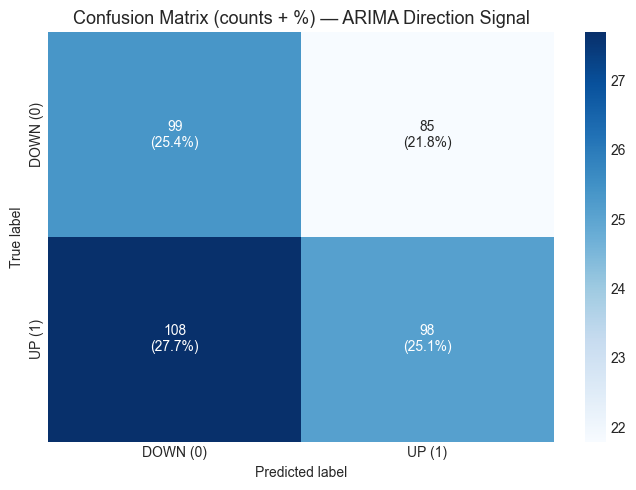

2026-06-03 12:06:04 | INFO | False positives (pred UP, actual DOWN): 85
2026-06-03 12:06:04 | INFO | False negatives (pred DOWN, actual UP): 108


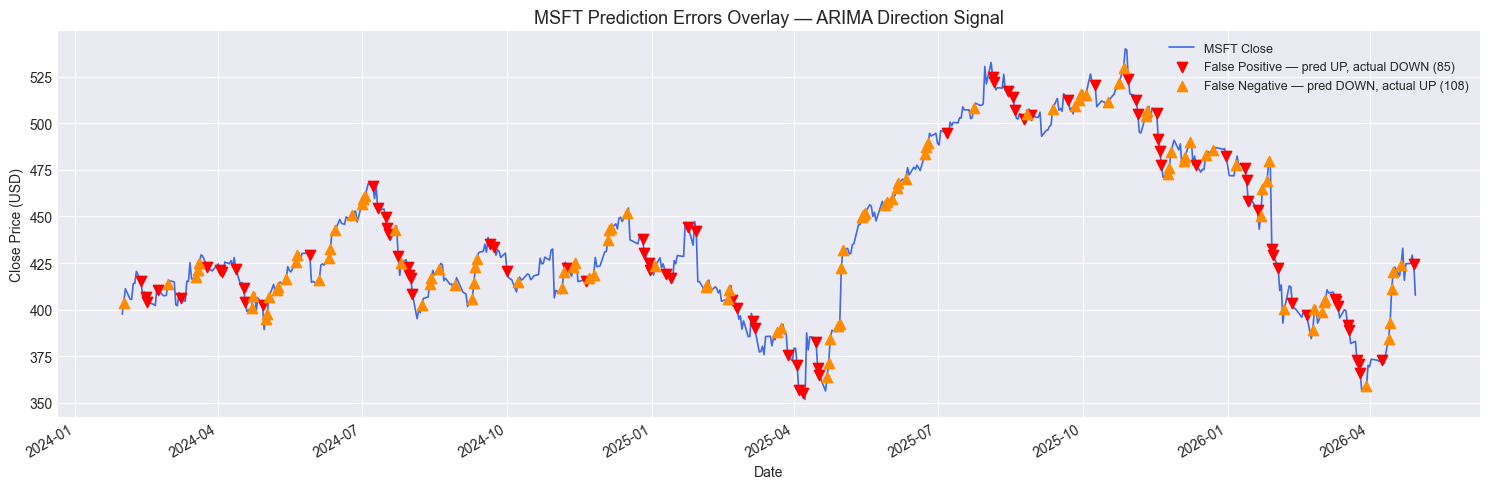

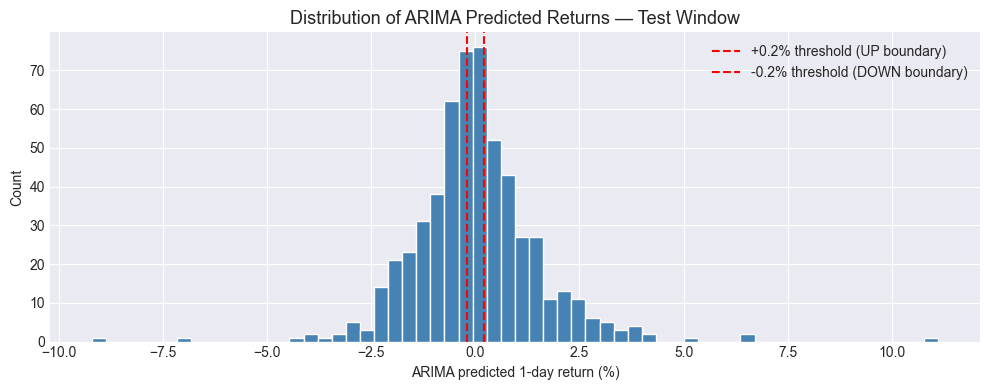

In [30]:
# Confusion matrix with counts and percentages
cm     = confusion_matrix(y_test_arima, y_pred_arima)
cm_pct = cm.astype(float) / cm.sum() * 100
annot  = np.array([
    [f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_pct, annot=annot, fmt="", cmap="Blues",
    xticklabels=["DOWN (0)", "UP (1)"],
    yticklabels=["DOWN (0)", "UP (1)"],
    ax=ax,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (counts + %) — ARIMA Direction Signal")
plt.tight_layout()
plt.show()

# Locate false positives and false negatives
eval_index   = y_test_arima.index
ypred_series = pd.Series(y_pred_arima.values, index=eval_index)
false_pos    = eval_index[(ypred_series == 1) & (y_test_arima == 0)]
false_neg    = eval_index[(ypred_series == 0) & (y_test_arima == 1)]

logger.info("False positives (pred UP, actual DOWN): %d", len(false_pos))
logger.info("False negatives (pred DOWN, actual UP): %d", len(false_neg))

# Error overlay on MSFT close price
close_test_window = df_raw.loc[df_raw.index >= test_start_date, close_col]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    close_test_window.index, close_test_window.values,
    color="royalblue", linewidth=1.2, label="MSFT Close",
)
ax.scatter(
    false_pos,
    close_test_window.reindex(false_pos).values,
    color="red", marker="v", s=55, zorder=5,
    label=f"False Positive — pred UP, actual DOWN ({len(false_pos)})",
)
ax.scatter(
    false_neg,
    close_test_window.reindex(false_neg).values,
    color="darkorange", marker="^", s=55, zorder=5,
    label=f"False Negative — pred DOWN, actual UP ({len(false_neg)})",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.set_title("MSFT Prediction Errors Overlay — ARIMA Direction Signal")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Distribution of ARIMA's predicted returns (shows confidence / neutral zone)
pred_returns_series = pd.Series(
    predicted_returns,
    index=close_test.index,
    name="ARIMA predicted return (%)",
)
fig, ax = plt.subplots(figsize=(10, 4))
pred_returns_series.hist(bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.axvline( NEUTRAL_THRESHOLD, color="red", linestyle="--",
            label=f"+{NEUTRAL_THRESHOLD}% threshold (UP boundary)")
ax.axvline(-NEUTRAL_THRESHOLD, color="red", linestyle="--",
            label=f"-{NEUTRAL_THRESHOLD}% threshold (DOWN boundary)")
ax.set_xlabel("ARIMA predicted 1-day return (%)")
ax.set_ylabel("Count")
ax.set_title("Distribution of ARIMA Predicted Returns — Test Window")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 10 — Rolling-Window Cross-Validation

`TimeSeriesSplit` with `cross_val_score` cannot be applied to ARIMA because it is
not a scikit-learn estimator. Instead, a manual rolling-window CV is implemented:
the dataset is divided into `N_FOLDS + 1` equal blocks; fold *k* uses blocks 0–k as
training data and block k+1 as the test window — exactly the logic of `TimeSeriesSplit`.

The fixed `ARIMA_ORDER` found by `auto_arima` on the full training set is reused
across folds (rather than re-running `auto_arima` per fold) to keep runtime manageable.

> **Note:** 3 folds are used rather than 5 to keep runtime under 5 minutes.
> Each fold runs a full walk-forward loop over its test window.

2026-06-03 12:06:05 | INFO | CV fold 1/3: train=505 (2015-11-30 to 2017-11-29)  test=704 (2017-11-30 to 2020-09-17)
2026-06-03 12:06:40 | INFO | Fold 1 F1 = 0.5453
2026-06-03 12:06:40 | INFO | CV fold 2/3: train=504 (2018-09-18 to 2020-09-17)  test=704 (2020-09-18 to 2023-07-07)
2026-06-03 12:07:08 | INFO | Fold 2 F1 = 0.5113
2026-06-03 12:07:08 | INFO | CV fold 3/3: train=501 (2021-07-12 to 2023-07-07)  test=704 (2023-07-10 to 2026-04-28)
2026-06-03 12:07:35 | INFO | Fold 3 F1 = 0.5141


F1 per fold : [0.5453, 0.5113, 0.5141]
Mean F1     : 0.5236
Std dev     : 0.0154


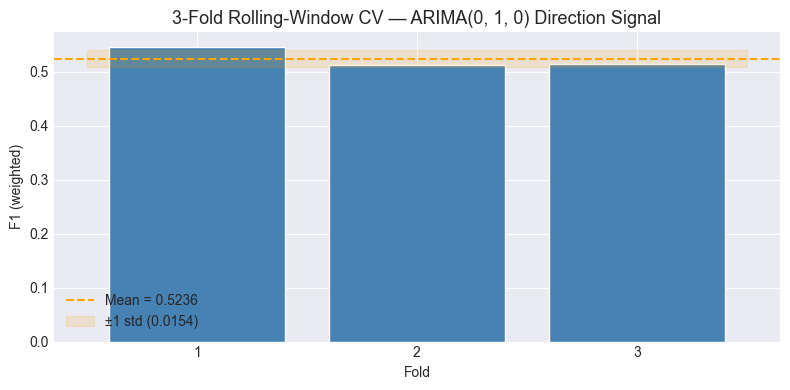

In [31]:
N_FOLDS = 3


def arima_direction_f1(
    close_train_fold: pd.Series,
    close_test_fold: pd.Series,
    target_test_fold: pd.Series,
    order: tuple,
    threshold: float = NEUTRAL_THRESHOLD,
) -> float:
    """Fit ARIMA(order) on a training fold, walk-forward on test fold, return F1.

    Parameters
    ----------
    close_train_fold : pd.Series
        Raw close prices for the training window.
    close_test_fold : pd.Series
        Raw close prices for the test window.
    target_test_fold : pd.Series
        Binary direction labels (0/1) for evaluation dates in the test window.
    order : tuple
        Fixed ARIMA(p,d,q) order to use.
    threshold : float
        Neutral zone threshold in percentage points.

    Returns
    -------
    float
        Weighted F1 score on the test fold (neutral predictions excluded).
    """
    fold_model = pm.ARIMA(order=order)
    fold_model.fit(close_train_fold)

    fold_forecasts = []
    for actual in close_test_fold.values:
        # np.ravel() works for both ndarray and Series output from pmdarima
        yhat = float(np.ravel(fold_model.predict(n_periods=1))[0])
        fold_forecasts.append(yhat)
        fold_model.update([actual])

    fold_returns   = (np.array(fold_forecasts) - close_test_fold.values) / close_test_fold.values * 100
    fold_direction = np.select(
        [fold_returns > threshold, fold_returns < -threshold],
        [1, 0],
        default=np.nan,
    )
    fold_dir_series = pd.Series(fold_direction, index=close_test_fold.index)

    common = target_test_fold.index.intersection(fold_dir_series.index)
    y_true = target_test_fold.loc[common]
    y_pred = fold_dir_series.loc[common]
    valid  = y_pred.notna()
    y_true, y_pred = y_true[valid], y_pred[valid].astype(int)

    if len(y_true) == 0:
        return float("nan")
    return f1_score(y_true, y_pred, average="weighted", zero_division=0)


# CV uses the same 2-year window logic: each training fold is limited to
# the 2 years preceding its test window to match the main experiment.
fold_size    = len(close_all) // (N_FOLDS + 1)
cv_f1_scores = []

for fold in range(N_FOLDS):
    train_end = fold_size * (fold + 1)
    test_end  = fold_size * (fold + 2)

    fold_close_test  = close_all.iloc[train_end:test_end]
    fold_test_start  = fold_close_test.index.min()

    # Last 2 years before this fold's test window
    fold_arima_cutoff = fold_test_start - pd.DateOffset(years=ARIMA_TRAIN_YEARS)
    fold_close_train  = close_all.loc[
        (close_all.index >= fold_arima_cutoff) & (close_all.index < fold_test_start)
    ]

    fold_test_end = fold_close_test.index.max()
    fold_target   = df.loc[
        (df.index >= fold_test_start) & (df.index <= fold_test_end), "target"
    ]

    logger.info(
        "CV fold %d/%d: train=%d (%s to %s)  test=%d (%s to %s)",
        fold + 1, N_FOLDS,
        len(fold_close_train),
        fold_close_train.index.min().date() if len(fold_close_train) else "N/A",
        fold_close_train.index.max().date() if len(fold_close_train) else "N/A",
        len(fold_close_test),
        fold_test_start.date(), fold_test_end.date(),
    )

    fold_f1 = arima_direction_f1(
        fold_close_train,
        fold_close_test,
        fold_target,
        order=ARIMA_ORDER,
    )
    cv_f1_scores.append(fold_f1)
    logger.info("Fold %d F1 = %.4f", fold + 1, fold_f1)

cv_scores_arr = np.array(cv_f1_scores)
print(f"F1 per fold : {[round(float(s), 4) for s in cv_scores_arr]}")
print(f"Mean F1     : {cv_scores_arr.mean():.4f}")
print(f"Std dev     : {cv_scores_arr.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, N_FOLDS + 1), cv_scores_arr, color="steelblue", edgecolor="white")
ax.axhline(
    cv_scores_arr.mean(), color="orange", linestyle="--", linewidth=1.5,
    label=f"Mean = {cv_scores_arr.mean():.4f}",
)
ax.fill_between(
    [0.5, N_FOLDS + 0.5],
    cv_scores_arr.mean() - cv_scores_arr.std(),
    cv_scores_arr.mean() + cv_scores_arr.std(),
    alpha=0.15, color="orange",
    label=f"±1 std ({cv_scores_arr.std():.4f})",
)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (weighted)")
ax.set_title(f"3-Fold Rolling-Window CV — ARIMA{ARIMA_ORDER} Direction Signal")
ax.set_xticks(range(1, N_FOLDS + 1))
ax.legend()
plt.tight_layout()
plt.show()

### Cross-Validation Interpretation

A **low standard deviation** across folds means ARIMA's direction signal is stable
across different historical time windows — a strong indicator of production reliability.

A **high standard deviation** suggests the signal is regime-dependent: ARIMA performs
well in trending markets (where AR momentum is useful) but degrades in choppy,
mean-reverting conditions.

If the mean CV F1 is close to the held-out test F1 from Section 8, the single test
window evaluation was representative. A substantially higher test F1 means the
2024–2026 period happened to be a particularly favourable window for ARIMA.

---
## Section 11 — Business Value Interpretation

### What the model predicts and for whom

Iteration 4 introduces a **pre-trained ARIMA price forecaster** as the direction signal:
1. ARIMA forecasts the next-day MSFT close price from the raw historical price series
2. Predicted return = (forecast − today's close) / today's close × 100
3. UP if predicted return > +0.2 %; DOWN if < −0.2 %; NEUTRAL otherwise
4. The model updates itself online each day — no manual retraining required

Target audience: **retail investors** using the MSFT Forecaster dashboard as a
decision-support tool, not an automated trading system.

### ARIMA vs Classifier — When Does Each Win?

| Condition | ARIMA likely better | XGBoost likely better |
|---|---|---|
| Strong price autocorrelation | Yes — AR terms capture it directly | No |
| Macro shock (rate change, earnings) | No — uses only price history | Yes — VIX, SPY, gold encode this |
| Online / streaming deployment | Yes — `.update()` is lightweight | Needs retraining pipeline |
| Market regime shift | No — AR coefficients drift | Depends on whether features adapt |

### Limitations

| Limitation | Impact |
|---|---|
| ARIMA uses only price history | Ignores VIX, gold, oil, SPY signals that XGBoost exploits |
| Near-random-walk prices → tight forecasts | Many days fall in the ±0.2 % neutral zone (no signal) |
| Linear autocorrelation only | Non-linear patterns, fat tails, regime breaks not captured |
| Fixed order (p,d,q) | Optimal order may drift over time; periodic re-selection recommended |

### Next Iteration Candidate

**Hybrid model (Iteration 5):** Feed ARIMA's predicted return as an *additional feature*
into XGBoost alongside the it3 technical and macro features. This combines the time
series structure from ARIMA with the macro signal from the classifiers — potentially
yielding higher F1 than either model alone.

### Dashboard Integration

The saved `arima_lucan_it4.pkl` can be used in the Streamlit dashboard to:
1. Call `model.predict(n_periods=1)` → tomorrow's forecast price
2. Display: predicted price, predicted return %, direction badge (UP / DOWN / NEUTRAL)
3. Call `model.update([today_close])` at end-of-day for online updating
4. Show confidence note: small predicted returns near neutral indicate low certainty
5. Include disclaimer that this is not financial advice